In [1]:
'''
Let's import useful and "standard" packages.
Not all packages will be used in the short course. It is my habit to import them
ahead of time.
'''

import numpy as np # numpy is a powerful package for numeric calculation, we rename it as "np"
import sys, os # these are system related packages
import pickle # pickle is a cute package to save and load your custom data
import shutil # for high-level file operations
import scipy, sklearn, skimage, math # these are useful packages for scientific computing, machine learning, image processing, and math calculation
import matplotlib.pyplot as plt # this is a powerful package for visualization, e.g., curves, bar charts, histograms, and various visualizations.
import cv2 # this is a powerful package for computer vision
from pathlib import Path
from PIL import Image
from sklearn.metrics import confusion_matrix
import random


In [2]:
'''
Let's import the famous PyTorch package, supporting deep learning.
It is convenient to give short names for useful functions inside PyTorch
'''
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.nn.functional as F
from torch.autograd import Variable
import torchvision
from torchvision import datasets, models, transforms
from torchvision.transforms import v2


In [3]:
def seed_everything(seed=42):
    """
    Sets the random seed for reproducibility across multiple libraries and devices.
    """
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # if you are using multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False # set to False for deterministic behavior
    # torch.backends.cudnn.enabled = False # can be set to False if needed
    print(f"Random seed set to {seed}")

# Usage:
seed_everything(0)

Random seed set to 0


In [4]:
# Set the global random seed for reproducibility
np.random.seed(0) 


# set device, which gpu to use.
device ='cpu'
if torch.cuda.is_available(): 
    device='cuda:0'
print(device)

cuda:0


# config hyperparameters

In [5]:
batch_size = 64
epoch_num = 100
# lr = 0.0005 # base learning rate
weight_decay = 0.0001


exp_dir = './exp' # experiment directory, used for reading the init model
prefix = 'vanilla'
postfix = 'v1'

project_name = prefix + '_' + postfix   # we save all the checkpoints in this directory
print(project_name)

save_dir = os.path.join(exp_dir, project_name)

log_filename = os.path.join(save_dir, 'train_%f.log' % weight_decay)
print(save_dir)

if not os.path.exists(save_dir): os.makedirs(save_dir)


vanilla_v1
./exp/vanilla_v1


# make PyTorch-friendly dataloaders for train and validation sets

In [6]:
filename_train = 'cls_train.pkl'
filename_val = 'cls_val.pkl'

with open(filename_train, 'rb') as file:
    trainset_info = pickle.load(file)

with open(filename_val, 'rb') as file:
    valset_info = pickle.load(file)

train_labellist = trainset_info['train_labellist']
val_labellist = valset_info['val_labellist']

numClasses = max(train_labellist)+1

## a helper to read data


In [7]:
class pollenDataset(Dataset):
    def __init__(self, imgpathList, labelList, transform=None, is_trainset=False):
        self.imgpathList = imgpathList
        self.labelList = labelList
        self.transform = transform
        self.current_set_len = len(labelList)
        self.is_trainset = is_trainset
        
    def __len__(self):        
        return self.current_set_len
    
    def __getitem__(self, idx):        
        cur_img = self.imgpathList[idx]
        cur_label = self.labelList[idx]
        cur_img = skimage.io.imread(cur_img).astype(np.float32) / 255.0
        # cur_img = Image.fromarray(cur_img)
        # cur_img = Image.open(cur_img) 
        # print(cur_img.max(),cur_img.min())

        if self.is_trainset:
            if np.random.rand()>0.5:
                cur_img[:,:,0] = np.fliplr(cur_img[:,:,0])
                cur_img[:,:,1] = np.fliplr(cur_img[:,:,1])
                cur_img[:,:,2] = np.fliplr(cur_img[:,:,2])
            if np.random.rand()>0.5:
                cur_img[:,:,0] = np.flipud(cur_img[:,:,0])
                cur_img[:,:,1] = np.flipud(cur_img[:,:,1])
                cur_img[:,:,2] = np.flipud(cur_img[:,:,2])

        
        if self.transform is not None:
            cur_img = self.transform(cur_img)
            # print('       ', cur_img.max(),cur_img.min())
        return cur_img, cur_label

In [8]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

data_train_transform = transforms.Compose([
    # v2.RandomResize(min_size=240, max_size=300),
    # transforms.RandomCrop(224),
    # transforms.RandomHorizontalFlip(),
    # transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


data_val_transform = transforms.Compose([
    # transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [9]:
trainset = pollenDataset(imgpathList=trainset_info['train_imgpathlist'],
                         labelList=train_labellist,
                         transform=data_train_transform,
                         is_trainset=True
                        )

valset = pollenDataset(imgpathList=valset_info['val_imgpathlist'],
                       labelList=val_labellist,
                       transform=data_val_transform,
                       is_trainset=False
                      )

In [10]:
print(len(trainset), len(valset))

1275 319


In [11]:
dataloader_trainset = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=4)
dataloader_valset = DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=4)

print(len(dataloader_trainset), len(dataloader_valset))

20 5


In [12]:
cur_img = trainset_info['train_imgpathlist'][0]
cur_label = train_labellist[0]
cur_img = skimage.io.imread(cur_img).astype(np.float32) / 255.0

# cur_img = Image.fromarray(cur_img)
# cur_img = Image.open(cur_img) 
# print(cur_img.max(),cur_img.min())

In [13]:
type(cur_img), cur_img.max(), cur_img.min(), cur_img.shape

(numpy.ndarray, 1.0, 0.0, (240, 240, 3))

In [14]:
# cur_img = data_train_transform(cur_img)
# type(cur_img), cur_img.max(), cur_img.min()

In [15]:
cur_img2 = trainset_info['train_imgpathlist'][0]
cur_img2 = Image.open(cur_img2)

In [16]:
cur_img2 = np.asarray(cur_img2)


In [17]:
type(cur_img2), cur_img2.max(), cur_img2.min(), cur_img2.shape

(numpy.ndarray, 255, 0, (240, 240, 3))

In [18]:
# cur_img = np.transpose(cur_img, axes=(1, 2, 0))

In [19]:
# cur_img-cur_img2

In [20]:
i = 0
for sample in dataloader_trainset:
    i+=1
    if i%10==0:
        print(i)
    cur_Img, cur_Label = sample
    cur_Img = cur_Img.to(device)
    cur_Label = cur_Label.to(device)

10
20


In [21]:
cur_Img.shape, cur_Label.shape, cur_Img.min(), cur_Img.max()

(torch.Size([59, 3, 240, 240]),
 torch.Size([59]),
 tensor(-2.1179, device='cuda:0'),
 tensor(2.6400, device='cuda:0'))

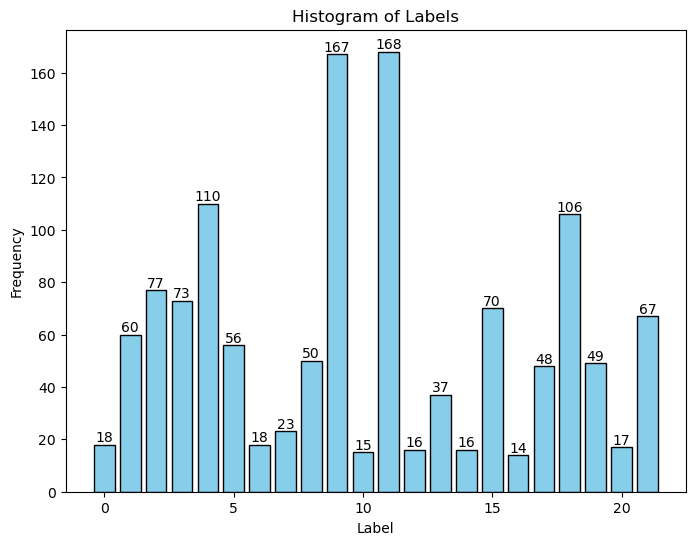

In [22]:
unique_labels, counts = np.unique(train_labellist, return_counts=True)


plt.figure(figsize=(8, 6))
plt.bar(unique_labels, counts, color='skyblue', edgecolor='black')

# Add axis labels and title
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.title('Histogram of Labels')

# Add frequency labels on top of the bars
for i in range(len(counts)):
    plt.text(unique_labels[i], counts[i], str(counts[i]), ha='center', va='bottom')

plt.show()

In [23]:
unique_labels

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21])

In [24]:
per_class_weight = np.asarray(counts)
per_class_weight = per_class_weight.sum() /  per_class_weight
per_class_weight /= per_class_weight.sum()
per_class_weight = torch.from_numpy(per_class_weight.astype(np.float32)).to(device)

In [25]:
per_class_weight

tensor([0.0810, 0.0243, 0.0189, 0.0200, 0.0133, 0.0260, 0.0810, 0.0634, 0.0292,
        0.0087, 0.0972, 0.0087, 0.0912, 0.0394, 0.0912, 0.0208, 0.1042, 0.0304,
        0.0138, 0.0298, 0.0858, 0.0218], device='cuda:0')

# Set a Convolutional Neural Network (CNN)

In [26]:
class ModelArchitecture(nn.Module):
    def __init__(self, num_classes=20, pretrained=False):
        super().__init__()
        if pretrained:
            self.backbone = models.resnet18(weights='IMAGENET1K_V1') # or pretrained=True
        else:
            self.backbone = models.resnet18() # or pretrained=True
        self.backbone.fc = nn.Identity() # remove classification head
        feat_dim = 512
        self.dropout = nn.Dropout(0.5)         
        self.fc1 = nn.Linear(feat_dim, 64)
        self.fc2 = nn.Linear(64, num_classes)
    def forward(self, x):
        feat = self.backbone(x)
        feat = self.fc1(feat)
        feat = self.dropout(feat)
        logits = self.fc2(feat)
        # logits = self.cls_head(self.dropout(feat))
        return logits

In [27]:
pretrained = True
myModel = ModelArchitecture(num_classes=numClasses, pretrained=pretrained).to(device)
myModel.train()

ModelArchitecture(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True

In [28]:
def initialize_weights(module):
    if isinstance(module, nn.Linear):
        # Use Kaiming uniform initialization for Linear layers (good for ReLU networks)
        nn.init.kaiming_uniform_(module.weight, nonlinearity='relu')
        if module.bias is not None:
            # Set bias to zero
            nn.init.zeros_(module.bias)
    elif isinstance(module, nn.Conv2d):
        # Use Xavier uniform initialization for Conv2d layers
        nn.init.xavier_uniform_(module.weight)
        if module.bias is not None:
            nn.init.zeros_(module.bias)

myModel.fc1.apply(initialize_weights)
myModel.fc2.apply(initialize_weights)

Linear(in_features=64, out_features=22, bias=True)

In [29]:
output = myModel(cur_Img)

In [30]:
# loss_fn = nn.CrossEntropyLoss(weight=per_class_weight)
loss_fn = nn.CrossEntropyLoss()

# optimizer = optim.AdamW([{'params': myModel.backbone.parameters(), 'lr': 1e-4},
#     {'params': myModel.cls_head.parameters(), 'lr': 1e-3, 'weight_decay': 0.0005}]
#     lr=lr, betas=(0.9, 0.999), weight_decay=weight_decay)


# optimizer = optim.AdamW([
#     {'params': myModel.backbone.parameters(), 'lr': 1e-4},
#     {'params': myModel.cls_head.parameters(), 'lr': 1e-3, 'weight_decay': 0.001}], lr=1e-3, weight_decay=0.0005)

# optimizer = optim.AdamW([
#     # {'params': myModel.backbone.parameters(), 'lr': 1e-4},
#     {'params': myModel.cls_head.parameters(), 'lr': 1e-4, 'weight_decay': 0.00001}], lr=0, weight_decay=0.000)


# optimizer = optim.SGD([
#     {'params': myModel.backbone.parameters(), 'lr': 5e-4},
#     {'params': myModel.cls_head.parameters(), 'lr': 5e-3, 'weight_decay': 0.0001}], lr=0.0005, momentum=0.9)


# optimizer = optim.SGD([{'params': myModel.cls_head.parameters(), 'lr': 5e-3, 'weight_decay': 0.0005}])


optimizer = optim.AdamW([
    {'params': myModel.fc1.parameters(), 'lr': 1e-4, 'weight_decay': 0.0001},
    {'params': myModel.fc2.parameters(), 'lr': 1e-4, 'weight_decay': 0.0001}])

scheduler = lr_scheduler.CosineAnnealingLR(optimizer, epoch_num, eta_min=0)

# Train this CNN

In [31]:
def append_to_log(log_filename, content_string):
    fn = open(log_filename,'a')
    fn.write('{}\n'.format(content_string))    
    fn.close()


In [32]:
# temperature = 1.5

In [33]:
best_epoch_id = -1
best_loss = torch.inf
list_val_loss = np.zeros(epoch_num)
list_train_loss = np.zeros(epoch_num)
bestmodel_filename = os.path.join(save_dir, 'bestmodel_%f.params' % weight_decay)


fn = open(log_filename,'w')
fn.write('{}\n'.format(project_name))
fn.close()

for epoch in range(epoch_num):
    # training
    cur_string = 'epoch %d...' % (epoch)
    print(cur_string)
    append_to_log(log_filename, cur_string)
    
    myModel.eval();
    cur_loss = 0
    i=0
    for sample in dataloader_trainset:
        i+=1
        if i%20==0:
            cur_string = '\t%d / %d' %(i, len(dataloader_trainset))
            print(cur_string)
            append_to_log(log_filename, cur_string)

        cur_Img, cur_Label = sample
        cur_Img = cur_Img.to(device)
        cur_Label = cur_Label.type(torch.long).view(-1).to(device)

        
        optimizer.zero_grad()

        
        logits = myModel(cur_Img) 
        loss = loss_fn(logits, cur_Label)
        cur_loss += loss.data
    
        # backward pass
        loss.backward()
        # update weights
        optimizer.step()
        
    scheduler.step()
    cur_loss = cur_loss / len(dataloader_trainset)
    list_train_loss[epoch] = cur_loss
    cur_string = '\ttrain CE: %.4f' % (cur_loss)
    print(cur_string)
    append_to_log(log_filename, cur_string)
    
    # evaluation
    cur_string = '   evaluation...'
    print(cur_string)
    append_to_log(log_filename, cur_string)
    myModel.eval();
    cur_loss = 0
    for sample in dataloader_valset:
        cur_Img, cur_Label = sample
        cur_Img = cur_Img.to(device)
        cur_Label = cur_Label.to(device)
        output = myModel(cur_Img)
        tmp = loss_fn(output, cur_Label)
        cur_loss += tmp.data
    cur_loss = cur_loss/len(dataloader_valset)
    list_val_loss[epoch] = cur_loss
    
    if cur_loss<best_loss:
        best_epoch_id = epoch
        best_loss = cur_loss
        torch.save(myModel.state_dict(), bestmodel_filename)
        
    cur_string = '\tcurrent CE: %.4f, best CE: %.4f at epoch-%d' % (cur_loss, best_loss, best_epoch_id)
    print(cur_string)
    append_to_log(log_filename, cur_string)

epoch 0...
	20 / 20
	train CE: 4.0790
   evaluation...
	current CE: 3.5228, best CE: 3.5228 at epoch-0
epoch 1...
	20 / 20
	train CE: 3.3142
   evaluation...
	current CE: 3.1869, best CE: 3.1869 at epoch-1
epoch 2...
	20 / 20
	train CE: 3.0973
   evaluation...
	current CE: 3.0411, best CE: 3.0411 at epoch-2
epoch 3...
	20 / 20
	train CE: 2.9696
   evaluation...
	current CE: 2.9518, best CE: 2.9518 at epoch-3
epoch 4...
	20 / 20
	train CE: 2.8867
   evaluation...
	current CE: 2.8772, best CE: 2.8772 at epoch-4
epoch 5...
	20 / 20
	train CE: 2.8230
   evaluation...
	current CE: 2.8156, best CE: 2.8156 at epoch-5
epoch 6...
	20 / 20
	train CE: 2.7277
   evaluation...
	current CE: 2.7588, best CE: 2.7588 at epoch-6
epoch 7...
	20 / 20
	train CE: 2.6787
   evaluation...
	current CE: 2.7103, best CE: 2.7103 at epoch-7
epoch 8...
	20 / 20
	train CE: 2.6199
   evaluation...
	current CE: 2.6675, best CE: 2.6675 at epoch-8
epoch 9...
	20 / 20
	train CE: 2.5952
   evaluation...
	current CE: 2.628

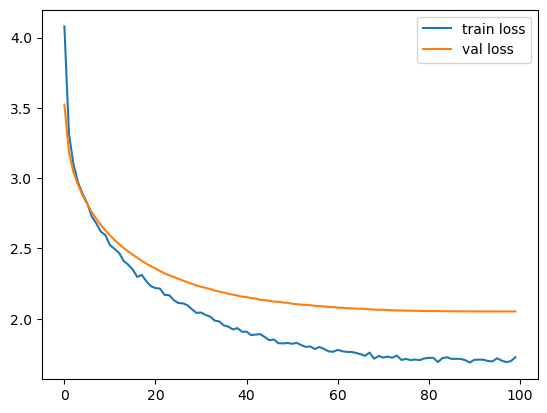

In [34]:
plt.plot(list_train_loss, label='train loss')
plt.plot(list_val_loss, label='val loss')
plt.legend()

# Use the last checkpoint

In [35]:
myModel.eval();
predList = []
for sample in dataloader_valset:
    cur_Img, cur_Label = sample
    cur_Img = cur_Img.to(device)
    cur_Label = cur_Label.to(device)
    logits = myModel(cur_Img).detach()
    output = F.softmax(logits, dim=0)
    output = output.cpu().numpy()
    output = np.argmax(output, 1)
    predList = np.concatenate((predList, output))

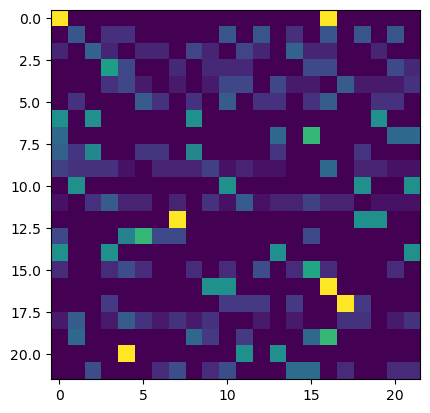

In [36]:
conf = sklearn.metrics.confusion_matrix(val_labellist, predList, normalize='true')

plt.imshow(conf)

In [37]:
per_class_acc = np.diag(conf)
print('mean accuracy: %.3f' % per_class_acc.mean())

mean accuracy: 0.157


# Use the selected checkpoint 

In [38]:
bestmodel_filename

'./exp/vanilla_v1/bestmodel_0.000100.params'

In [39]:
myModel = ModelArchitecture(num_classes=numClasses).to(device)
myModel.load_state_dict(torch.load(bestmodel_filename))

<All keys matched successfully>

In [40]:
# A = torch.load(bestmodel_filename)

In [41]:
myModel.eval();
predList = []
for sample in dataloader_valset:
    cur_Img, cur_Label = sample
    cur_Img = cur_Img.to(device)
    cur_Label = cur_Label.to(device)
    logits = myModel(cur_Img).detach()
    output = F.softmax(logits, dim=0)
    output = output.cpu().numpy()
    output = np.argmax(output, 1)
    predList = np.concatenate((predList, output))

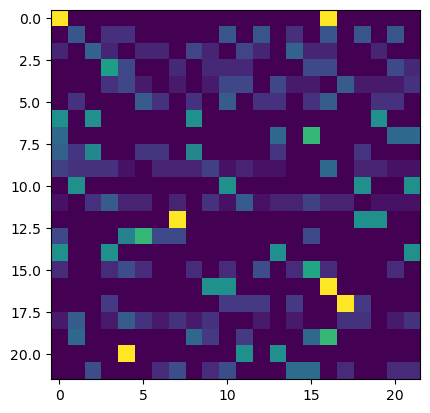

In [42]:
conf = sklearn.metrics.confusion_matrix(val_labellist, predList, normalize='true')

plt.imshow(conf)

In [43]:
per_class_acc = np.diag(conf)
print('mean accuracy: %.3f' % per_class_acc.mean())

mean accuracy: 0.157
